Assignment No: 1

Subject: Generative AI Lab
Name: Ragav Sharma

Class: B.Tech AI & ML
Batch: AIML

PRN: 202401110012

Date of Submission: 15/08/2026

# **Objective**

Implement a simple feedforward neural network from scratch in Python without using any in-built deep learning libraries.

The implementation includes:

Forward Pass
Backpropagation
Training using Gradient Descent
Loss calculation
Model evaluation

Only NumPy is used for the numerical implementation of the neural network. Matplotlib is used for visualization.

# **Part A: Problem Definition**
**Dataset**

The XNOR logic gate truth table is used as the dataset.

XNOR gives an output of 1 when both input values are the same and gives an output of 0 when the input values are different.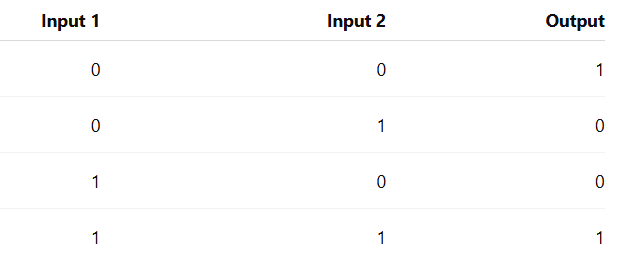




# **Task**

The task is to train a simple neural network to learn the behavior of the XNOR logic gate.

XNOR is a non-linearly separable problem. Therefore, a hidden layer is required for the neural network to learn the relationship between the inputs and output.


# **Import Required Libraries**

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# **Creating the Dataset**

In [3]:
import numpy as np

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([
    [1],
    [0],
    [0],
    [1]
], dtype=float)

print("Input Data:")
print(X)

print("\nExpected Output:")
print(y)


Input Data:
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Expected Output:
[[1.]
 [0.]
 [0.]
 [1.]]


# **Part B: Methodology**
**Neural Network Architecture **

The neural network contains:

2 neurons in the input layer
2 neurons in the hidden layer
1 neuron in the output layer
Sigmoid activation function in the hidden layer
Sigmoid activation function in the output layer
Mean Squared Error as the loss function
Gradient Descent as the optimization method
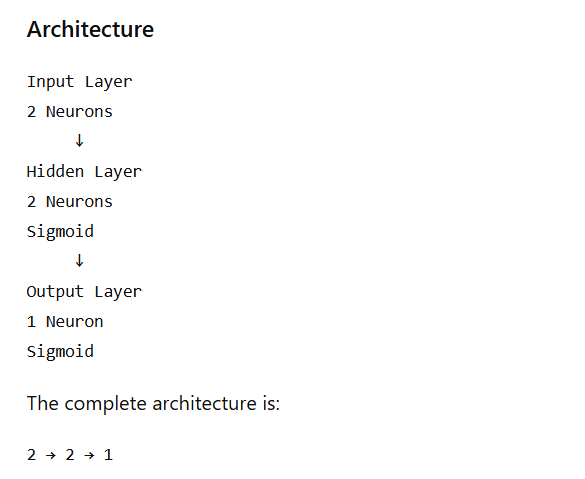

The two hidden neurons allow the network to learn the non-linear relationship required for the XNOR problem.

# **Initial Weights and Biases**

The initial weights and biases are manually supplied.

In [4]:

W1 = np.array([
    [0.4, -0.3],
    [0.2,  0.5]
], dtype=float)

b1 = np.array([
    [0.1, -0.2]
], dtype=float)

W2 = np.array([
    [0.3],
    [-0.4]
], dtype=float)

b2 = np.array([
    [0.1]
], dtype=float)

print("Initial W1:")
print(W1)

print("\nInitial b1:")
print(b1)

print("\nInitial W2:")
print(W2)

print("\nInitial b2:")
print(b2)

Initial W1:
[[ 0.4 -0.3]
 [ 0.2  0.5]]

Initial b1:
[[ 0.1 -0.2]]

Initial W2:
[[ 0.3]
 [-0.4]]

Initial b2:
[[0.1]]


Activation Function
The Sigmoid activation function is used in the hidden and output layers.

Sigmoid converts a value into a range between 0 and 1.

Sigmoid
σ(x) = 1 / (1 + e⁻ˣ)

Sigmoid Derivative
σ'(x) = σ(x)(1 - σ(x))

The derivative is required during backpropagation.

Loss Function
Mean Squared Error (MSE) is used to calculate the difference between the expected output and predicted output.

MSE = Mean((Actual - Predicted)²)

In [5]:

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def sigmoid_derivative(x):
    return x * (1 - x)


def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

Forward Pass
During forward propagation, the input data moves from the input layer towards the output layer.

Hidden Layer
Z1 = X · W1 + b1

A1 = Sigmoid(Z1)

Output Layer
Z2 = A1 · W2 + b2

A2 = Sigmoid(Z2)

A2 represents the predicted output of the neural network.

In [6]:

def forward_pass(X, W1, b1, W2, b2):

    Z1 = np.dot(X, W1) + b1

    A1 = sigmoid(Z1)

    Z2 = np.dot(A1, W2) + b2

    A2 = sigmoid(Z2)

    cache = (Z1, A1, Z2, A2)

    return A2, cache

In [7]:
initial_prediction, cache = forward_pass(
    X,
    W1,
    b1,
    W2,
    b2
)

initial_loss = mse(
    y,
    initial_prediction
)

print("Prediction Before Training:")
print(initial_prediction)

print("\nInitial MSE Loss:")
print(initial_loss)

Prediction Before Training:
[[0.51934717]
 [0.51063733]
 [0.53387839]
 [0.52509298]]

Initial MSE Loss:
0.25058510932278544


Backpropagation
Backpropagation calculates how much each weight and bias contributes to the prediction error.

The error is first calculated at the output layer and then propagated backward towards the hidden layer.

For Mean Squared Error:

dA2 = 2(A2 - y) / m

The Sigmoid derivative is then applied to calculate the output layer gradient.

The error is propagated to the hidden layer using the output layer weights.

Finally, gradients for W1, b1, W2 and b2 are calculated and used by gradient descent.

In [8]:
def backward_pass(X, y, cache, W2):

    Z1, A1, Z2, A2 = cache

    m = X.shape[0]

    dA2 = 2 * (A2 - y) / m

    dZ2 = dA2 * sigmoid_derivative(A2)

    dW2 = np.dot(A1.T, dZ2)

    db2 = np.sum(
        dZ2,
        axis=0,
        keepdims=True
    )

    dA1 = np.dot(
        dZ2,
        W2.T
    )

    dZ1 = (
        dA1 *
        sigmoid_derivative(A1)
    )

    dW1 = np.dot(
        X.T,
        dZ1
    )

    db1 = np.sum(
        dZ1,
        axis=0,
            keepdims=True
    )

    gradients = (
        dW1,
        db1,
        dW2,
        db2
    )

    return gradients

In [9]:
def update_weights(
    W1,
    b1,
    W2,
    b2,
    gradients,
    learning_rate
):

    dW1, db1, dW2, db2 = gradients

    W1 = W1 - learning_rate * dW1

    b1 = b1 - learning_rate * db1

    W2 = W2 - learning_rate * dW2

    b2 = b2 - learning_rate * db2

    return W1, b1, W2, b2

# **Part C: Training the Network**

The neural network is trained using gradient descent for a fixed number of epochs.

Training Parameters
Epochs = 10000
Learning Rate = 0.5

For every epoch:

Forward propagation is performed.
MSE loss is calculated.
Backpropagation calculates the gradients.
Gradient descent updates the weights and biases.
The loss is stored.

In [10]:

epochs = 10000
learning_rate = 0.5

loss_history = []


for epoch in range(epochs):

    # Forward pass
    y_pred, cache = forward_pass(
        X,
        W1,
        b1,
        W2,
        b2
    )

    # Calculate loss
    loss = mse(
        y,
        y_pred
    )

    loss_history.append(loss)

    # Backpropagation
    gradients = backward_pass(
        X,
        y,
        cache,
        W2
    )

    # Gradient descent
    W1, b1, W2, b2 = update_weights(
        W1,
        b1,
        W2,
        b2,
        gradients,
        learning_rate
    )

    if epoch % 1000 == 0:
        print(
            f"Epoch {epoch:5d} | Loss: {loss:.6f}"
        )


print(
    f"\nFinal Training Loss: {loss_history[-1]:.6f}"
)

Epoch     0 | Loss: 0.250585
Epoch  1000 | Loss: 0.249700
Epoch  2000 | Loss: 0.228396
Epoch  3000 | Loss: 0.043300
Epoch  4000 | Loss: 0.006202
Epoch  5000 | Loss: 0.003042
Epoch  6000 | Loss: 0.001977
Epoch  7000 | Loss: 0.001452
Epoch  8000 | Loss: 0.001143
Epoch  9000 | Loss: 0.000940

Final Training Loss: 0.000797


The loss decreases significantly during training, showing that the neural network is learning the XNOR relationship.

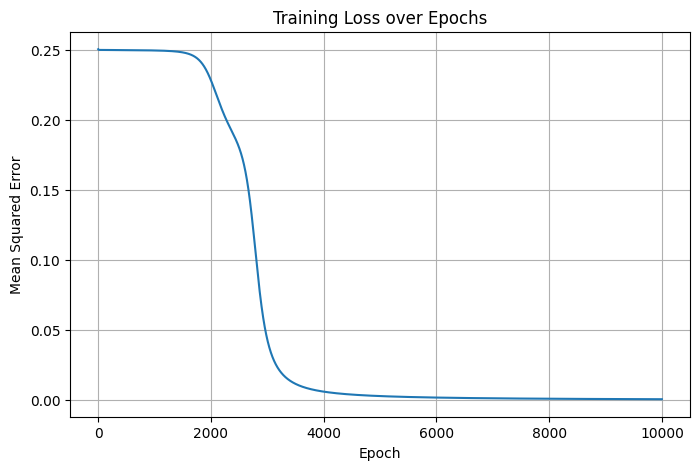

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.title("Training Loss over Epochs")

plt.xlabel("Epoch")

plt.ylabel("Mean Squared Error")

plt.grid(True)

plt.show()

# **Interpretation**

The loss curve decreases as the number of epochs increases.

At the beginning, the loss is approximately 0.250585.

After 10,000 epochs, the loss decreases to approximately 0.000797.

This indicates that gradient descent successfully adjusts the weights and biases to minimize the prediction error.

# **Part D: Evaluation**
After training, a final forward pass is performed using the XNOR input data.

The predicted probabilities are converted into binary values using a threshold of 0.5.

If predicted output >= 0.5 → 1

If predicted output < 0.5 → 0

The final predicted values are compared with the actual XNOR outputs.

In [12]:

final_prediction, _ = forward_pass(
    X,
    W1,
    b1,
    W2,
    b2
)

binary_prediction = (
    final_prediction >= 0.5
).astype(int)

print("Final Predicted Values:")

print(
    np.round(
        final_prediction,
        4
    )
)

print("\nBinary Predictions:")

print(binary_prediction)

Final Predicted Values:
[[0.9717]
 [0.0262]
 [0.0326]
 [0.9748]]

Binary Predictions:
[[1]
 [0]
 [0]
 [1]]


In [13]:
print("Input\t\tActual\tPredicted")

for i in range(len(X)):

    print(
        X[i],
        "\t",
        int(y[i][0]),
        "\t",
        int(binary_prediction[i][0])
    )

Input		Actual	Predicted
[0. 0.] 	 1 	 1
[0. 1.] 	 0 	 0
[1. 0.] 	 0 	 0
[1. 1.] 	 1 	 1


In [14]:
accuracy = np.mean(
    binary_prediction == y
) * 100

print(
    f"Accuracy: {accuracy:.2f}%"
)

Accuracy: 100.00%


In [15]:
print("Final W1:")
print(W1)

print("\nFinal b1:")
print(b1)

print("\nFinal W2:")
print(W2)

print("\nFinal b2:")
print(b2)

Final W1:
[[-5.30099559 -6.02133925]
 [ 5.54705042  6.00997012]]

Final b1:
[[ 2.63778393 -3.31952987]]

Final W2:
[[ 8.31997171]
 [-8.54620177]]

Final b2:
[[-3.93085193]]


# **Part E: Analysis of the Implemented Model**
The implemented neural network uses a 2-2-1 architecture.

The XNOR problem is non-linearly separable, which means that a single linear decision boundary cannot correctly separate all four input combinations.

For this reason, a hidden layer is required.

The two neurons in the hidden layer allow the network to learn an intermediate non-linear representation of the input data.

During training, the Mean Squared Error decreases continuously, showing that backpropagation and gradient descent are successfully updating the weights and biases.

After training, the neural network correctly predicts all four XNOR combinations.

Comparison with a Single-Layer Neural Network
To understand the importance of the hidden layer, the implemented 2-2-1 neural network is compared with a simple single-layer neural network having only 2 input neurons and 1 output neuron.

The single-layer network does not contain a hidden layer.

Since XNOR is non-linearly separable, the single-layer model is expected to perform poorly compared with the neural network containing a hidden layer.

In [16]:
single_W = np.array([
    [0.4],
    [-0.3]
], dtype=float)

single_b = np.array([
    [0.1]
], dtype=float)

single_learning_rate = 0.5
single_epochs = 10000

single_loss_history = []


for epoch in range(single_epochs):

    # Forward pass
    single_Z = np.dot(X, single_W) + single_b

    single_output = sigmoid(single_Z)


    # MSE Loss
    single_loss = mse(
        y,
        single_output
    )

    single_loss_history.append(
        single_loss
    )


    # Backpropagation
    m = X.shape[0]

    dA = 2 * (
        single_output - y
    ) / m

    dZ = (
        dA *
        sigmoid_derivative(single_output)
    )

    dW = np.dot(
        X.T,
        dZ
    )

    db = np.sum(
        dZ,
        axis=0,
        keepdims=True
    )


    # Gradient descent
    single_W -= (
        single_learning_rate * dW
    )

    single_b -= (
        single_learning_rate * db
    )




In [17]:
single_output = sigmoid(
    np.dot(X, single_W) + single_b
)

single_prediction = (
    single_output >= 0.5
).astype(int)

single_accuracy = np.mean(
    single_prediction == y
) * 100

single_final_loss = mse(
    y,
    single_output
)

print("Single-Layer Output:")
print(
    np.round(
        single_output,
        4
    )
)

print("\nSingle-Layer Prediction:")
print(single_prediction)

print(
    "\nSingle-Layer Final MSE:",
    round(single_final_loss, 6)
)

print(
    "Single-Layer Accuracy:",
    f"{single_accuracy:.2f}%"
)


Single-Layer Output:
[[0.5]
 [0.5]
 [0.5]
 [0.5]]

Single-Layer Prediction:
[[1]
 [1]
 [1]
 [1]]

Single-Layer Final MSE: 0.25
Single-Layer Accuracy: 50.00%


In [18]:
main_accuracy = np.mean(
    binary_prediction == y
) * 100

main_final_loss = mse(
    y,
    final_prediction
)

print("MODEL COMPARISON")
print("----------------------------")

print("Single-Layer Network")
print(
    "Final MSE:",
    round(single_final_loss, 6)
)
print(
    "Accuracy:",
    f"{single_accuracy:.2f}%"
)

print("\n2-2-1 Neural Network")
print(
    "Final MSE:",
    round(main_final_loss, 6)
)
print(
    "Accuracy:",
    f"{main_accuracy:.2f}%"
)


MODEL COMPARISON
----------------------------
Single-Layer Network
Final MSE: 0.25
Accuracy: 50.00%

2-2-1 Neural Network
Final MSE: 0.000797
Accuracy: 100.00%


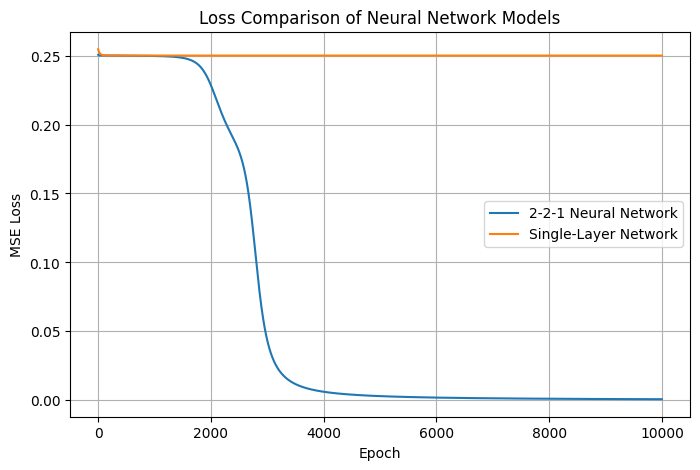

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    loss_history,
    label="2-2-1 Neural Network"
)

plt.plot(
    single_loss_history,
    label="Single-Layer Network"
)

plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.title(
    "Loss Comparison of Neural Network Models"
)

plt.legend()

plt.grid(True)

plt.show()

# **Model Strengths**

The main strengths of the implemented model are:

The neural network is implemented completely from scratch.
Forward propagation is implemented manually.
Backpropagation is implemented manually.
Gradient descent is implemented manually.
No TensorFlow, Keras, or PyTorch is used.
The network successfully learns a non-linear problem.
The training process is visualized using a loss curve.
The final predictions are easy to interpret.

# **Limitations**

The model also has some limitations:

The XNOR dataset contains only four samples.
The model is evaluated on the same samples used during training.
Therefore, the 100% accuracy does not demonstrate real-world generalization.
The network uses only two hidden neurons.
Mean Squared Error is used instead of binary cross-entropy.
Only basic gradient descent is used.

# **Learning Outcome**

This experiment provides an understanding of the internal working of a basic neural network without using high-level deep learning libraries.

The implementation demonstrates:

Input features
Weights
Biases
Weighted sums
Activation functions
Forward propagation
Loss calculation
Backpropagation
Gradient calculation
Gradient descent
Weight updates
Prediction
Model evaluation

The experiment also demonstrates why hidden layers are useful for learning non-linearly separable problems.

# **Conclusion**

A simple feedforward neural network was successfully implemented from scratch using NumPy.

The network was trained to learn the XNOR logic gate using a 2-2-1 architecture.

Sigmoid activation was used in both the hidden and output layers, while Mean Squared Error was used as the loss function.

Forward propagation, backpropagation, gradient calculation, and gradient descent were implemented manually without using TensorFlow, Keras, PyTorch, or any other deep learning framework.

The MSE loss decreased from approximately 0.250585 to 0.000797 during training.

The final predictions were:

[1, 0, 0, 1]

which correctly represent the XNOR truth table.

The model achieved 100% accuracy on the four XNOR samples.

This experiment demonstrates the fundamental working principles of a neural network and provides a practical understanding of how forward propagation, backpropagation, loss functions, gradients, and gradient descent work together during neural-network training.

# **Declaration**

I, Ragav Sharma, confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines.

Signature: Ragav Sharma